### Importation des bibliothèques

#### Objectif: cette première partie consiste à importer toutes les bibliothèques nécessaires pour préparer les données,

####  entraîner les modèles de Machine Learning, évaluer leurs performances et sauvegarder les résultats.


In [10]:
from catboost import CatBoostRegressor

print("CatBoost installé avec succès.")

CatBoost installé avec succès.


In [ ]:
# Gestion des avertissements
import warnings
warnings.filterwarnings("ignore")

# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Mesure du temps d'exécution
import time

# Sauvegarde des modèles
import joblib
import os

# Configuration des graphiques
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Toutes les bibliothèques ont été importées avec succès.")


In [ ]:
# Validation temporelle
from sklearn.model_selection import TimeSeriesSplit

# Métriques d'évaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# Modèles de Machine Learning
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


# Configuration des graphiques
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Toutes les bibliothèques ont été importées avec succès.")


In [3]:
# Vérification
print("Pandas :", pd.__version__)
print("NumPy :", np.__version__)

Pandas : 2.2.3
NumPy : 2.1.3


 #### Chargement du dataset

In [5]:
data = pd.read_excel(
    "C:/Users/LENOVO/Documents/Soutenance/Project_soutenance/data/processed/orbit_dataset_engineering.xlsx"
)

print("Dataset chargé avec succès.")


Dataset chargé avec succès.


#### Affichage des dimensions

In [14]:
print("Dimensions du dataset :", data.shape)
data.head() 

Dimensions du dataset : (116720, 51)


,id_point,date_collecte,latitude,longitude,fillRate,fillRate_t_minus_1,fillRate_t_minus_2,delta_fillRate_24h,rolling_mean_3d,fillRate_target_t_plus_1,...,quartier_14,rendement_remplissage,pression_citoyenne,ratio_plaintes,indice_meteo,pression_collecte,charge_precollecteur,indice_saturation,indice_priorite,risque_debordement
0,0,2022-01-03,4.001501,9.73807,49.55,33.98,12.98,15.58,32.17,6.00,...,False,133.328571,0,0.0,1714.44,99.10,16.516667,908846.10,0.0,1594.0235
1,0,2022-01-04,4.001501,9.73807,6.00,49.55,33.98,-43.56,29.84,21.43,...,False,15.371429,0,0.0,2052.27,0.00,3.000000,110052.00,0.0,179.0400
2,0,2022-01-05,4.001501,9.73807,21.43,6.00,49.55,15.43,25.66,36.56,...,False,55.434286,0,0.0,1916.20,21.43,10.715000,393069.06,0.0,549.8938
3,0,2022-01-06,4.001501,9.73807,36.56,21.43,6.00,15.13,21.33,52.21,...,False,96.278571,0,0.0,2138.16,73.12,9.140000,670583.52,0.0,779.8248
4,0,2022-01-07,4.001501,9.73807,52.21,36.56,21.43,15.65,36.73,72.72,...,False,139.950000,0,0.0,1740.92,156.63,13.052500,957635.82,0.0,1917.6733


#### Aperçu des dernières lignes

In [15]:
data.tail() 

,id_point,date_collecte,latitude,longitude,fillRate,fillRate_t_minus_1,fillRate_t_minus_2,delta_fillRate_24h,rolling_mean_3d,fillRate_target_t_plus_1,...,quartier_14,rendement_remplissage,pression_citoyenne,ratio_plaintes,indice_meteo,pression_collecte,charge_precollecteur,indice_saturation,indice_priorite,risque_debordement
116715,79,2025-12-27,3.940558,9.668905,57.85,41.36,31.75,16.49,43.66,2.79,...,False,168.150909,1,0.0,2036.16,289.25,9.641667,483626.0,57.85,2525.7310
116716,79,2025-12-28,3.940558,9.668905,2.79,57.85,41.36,-55.07,34.00,9.99,...,False,8.410909,0,0.0,1530.69,0.00,0.465000,23324.4,0.00,94.8600
116717,79,2025-12-29,3.940558,9.668905,9.99,2.79,57.85,7.21,23.54,20.24,...,False,25.906364,0,0.0,2175.66,9.99,1.248750,83516.4,0.00,235.1646
116718,79,2025-12-30,3.940558,9.668905,20.24,9.99,2.79,10.25,11.01,8.94,...,False,61.890000,0,0.0,1861.75,40.48,3.373333,169206.4,0.00,222.8424
116719,79,2025-12-31,3.940558,9.668905,8.94,20.24,9.99,-11.31,13.06,13.55,...,False,22.825455,0,0.0,1860.48,0.00,1.490000,74738.4,0.00,116.7564


#### Liste des colonnes

In [18]:

print("Nombre de colonnes :", len(data.columns))
print(data.columns.tolist())


Nombre de colonnes : 51
['id_point', 'date_collecte', 'latitude', 'longitude', 'fillRate', 'fillRate_t_minus_1', 'fillRate_t_minus_2', 'delta_fillRate_24h', 'rolling_mean_3d', 'fillRate_target_t_plus_1', 'nb_signalements_citoyens', 'nb_plaintes', 'nb_precollecteurs_dispo', 'jours_depuis_derniere_collecte', 'capacity_m3', 'poids_kg', 'densite_population_hab_km2', 'jour_semaine_num', 'is_weekend', 'is_jour_marche', 'temperature_celsius', 'humidite_pct', 'statut_prevu', 'priorite_recommandee', 'arrondissement_1', 'arrondissement_2', 'arrondissement_3', 'arrondissement_4', 'quartier_1', 'quartier_2', 'quartier_3', 'quartier_4', 'quartier_5', 'quartier_6', 'quartier_7', 'quartier_8', 'quartier_9', 'quartier_10', 'quartier_11', 'quartier_12', 'quartier_13', 'quartier_14', 'rendement_remplissage', 'pression_citoyenne', 'ratio_plaintes', 'indice_meteo', 'pression_collecte', 'charge_precollecteur', 'indice_saturation', 'indice_priorite', 'risque_debordement']


#### Vérification du type de chaque variable

In [17]:
data.dtypes 

id_point                                   int64
date_collecte                     datetime64[ns]
latitude                                 float64
longitude                                float64
fillRate                                 float64
fillRate_t_minus_1                       float64
fillRate_t_minus_2                       float64
delta_fillRate_24h                       float64
rolling_mean_3d                          float64
fillRate_target_t_plus_1                 float64
nb_signalements_citoyens                   int64
nb_plaintes                                int64
nb_precollecteurs_dispo                    int64
jours_depuis_derniere_collecte             int64
capacity_m3                                int64
poids_kg                                 float64
densite_population_hab_km2                 int64
jour_semaine_num                           int64
is_weekend                                 int64
is_jour_marche                             int64
temperature_celsius 

#### Variable cible

In [15]:

y = data["fillRate_target_t_plus_1"]

print("Variable cible créée.")
print(y.head())

Variable cible créée.
0     6.00
1    21.43
2    36.56
3    52.21
4    72.72
Name: fillRate_target_t_plus_1, dtype: float64


#### Colonnes à supprimer

In [16]:

colonnes_a_supprimer = [

    "id_point",

    "date_collecte",

    "fillRate_target_t_plus_1"

]

#### Variables explicatives

In [17]:

X = data.drop(columns=colonnes_a_supprimer)

print("Variables explicatives créées.")


Variables explicatives créées.


#### Vérification


In [18]:
print("Dimensions de X :", X.shape)

print("Dimensions de y :", y.shape)

Dimensions de X : (116720, 48)
Dimensions de y : (116720,)


#### Vérification des types: Toutes les modèles que nous allons utiliser attendent des variables numériques.


In [19]:
print(X.dtypes.value_counts())

float64    18
bool       18
int64      12
Name: count, dtype: int64


#### Conversion des booléens

In [20]:

bool_cols = X.select_dtypes("bool").columns

X[bool_cols] = X[bool_cols].astype(int)

print("Variables booléennes converties.")

Variables booléennes converties.


#### Vérification finale

In [29]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116720 entries, 0 to 116719
Data columns (total 48 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   latitude                        116720 non-null  float64
 1   longitude                       116720 non-null  float64
 2   fillRate                        116720 non-null  float64
 3   fillRate_t_minus_1              116720 non-null  float64
 4   fillRate_t_minus_2              116720 non-null  float64
 5   delta_fillRate_24h              116720 non-null  float64
 6   rolling_mean_3d                 116720 non-null  float64
 7   nb_signalements_citoyens        116720 non-null  int64  
 8   nb_plaintes                     116720 non-null  int64  
 9   nb_precollecteurs_dispo         116720 non-null  int64  
 10  jours_depuis_derniere_collecte  116720 non-null  int64  
 11  capacity_m3                     116720 non-null  int64  
 12  poids_kg        

#### Valeurs infinies

In [31]:
import numpy as np

print(np.isinf(X).sum().sum())


0


#### Si le résultat est supérieur à 0 :

In [21]:
X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(0)

print("Valeurs infinies corrigées.")

Valeurs infinies corrigées.


#### Vérification finale

In [22]:
print("="*50)

print("Nombre d'observations :", X.shape[0])

print("Nombre de variables :", X.shape[1])

print("Valeurs manquantes :", X.isnull().sum().sum())

print("Valeurs infinies :", np.isinf(X).sum().sum())

print("="*50)

Nombre d'observations : 116720
Nombre de variables : 48
Valeurs manquantes : 0
Valeurs infinies : 0


### Validation temporelle (TimeSeriesSplit)

#### Vérification de la colonne date

In [6]:
print(data["date_collecte"].head())


0   2022-01-03
1   2022-01-04
2   2022-01-05
3   2022-01-06
4   2022-01-07
Name: date_collecte, dtype: datetime64[ns]


In [7]:
print(data["date_collecte"].tail())

116715   2025-12-27
116716   2025-12-28
116717   2025-12-29
116718   2025-12-30
116719   2025-12-31
Name: date_collecte, dtype: datetime64[ns]


#### Conversion de la date
#### Même si la colonne est déjà convertie, cette étape garantit le bon format.


In [23]:
data["date_collecte"] = pd.to_datetime(data["date_collecte"])

print("Date convertie avec succès.")

Date convertie avec succès.


#### Faisons un tri chronologique

In [24]:

data = data.sort_values("date_collecte")

data = data.reset_index(drop=True)

print("Dataset trié par date.")

Dataset trié par date.


#### Vérification

In [25]:
print(data["date_collecte"].head())

0   2022-01-03
1   2022-01-03
2   2022-01-03
3   2022-01-03
4   2022-01-03
Name: date_collecte, dtype: datetime64[ns]


In [9]:
print(data["date_collecte"].tail())

116715   2025-12-27
116716   2025-12-28
116717   2025-12-29
116718   2025-12-30
116719   2025-12-31
Name: date_collecte, dtype: datetime64[ns]


#### Création du TimeSeriesSplit: Validation temporelle

In [26]:
tscv = TimeSeriesSplit(
    n_splits=5
)

print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


#### Visualisation des différents découpages temporelles


In [27]:
fold = 1

for train_index, test_index in tscv.split(X):

    print("=" * 60)

    print(f"Fold {fold}")

    print("=" * 60)

    print("Train :", len(train_index))

    print("Test  :", len(test_index))

    print("Début Train :", train_index[0])

    print("Fin Train   :", train_index[-1])

    print("Début Test  :", test_index[0])

    print("Fin Test    :", test_index[-1])

    fold += 1

Fold 1
Train : 19455
Test  : 19453
Début Train : 0
Fin Train   : 19454
Début Test  : 19455
Fin Test    : 38907
Fold 2
Train : 38908
Test  : 19453
Début Train : 0
Fin Train   : 38907
Début Test  : 38908
Fin Test    : 58360
Fold 3
Train : 58361
Test  : 19453
Début Train : 0
Fin Train   : 58360
Début Test  : 58361
Fin Test    : 77813
Fold 4
Train : 77814
Test  : 19453
Début Train : 0
Fin Train   : 77813
Début Test  : 77814
Fin Test    : 97266
Fold 5
Train : 97267
Test  : 19453
Début Train : 0
Fin Train   : 97266
Début Test  : 97267
Fin Test    : 116719


#### Utilisation du dernier Fold Pour entraîner les modèles, nous utiliserons le dernier découpage.

In [28]:
for train_index, test_index in tscv.split(X):

    X_train = X.iloc[train_index]

    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]

    y_test = y.iloc[test_index]

#### Vérification des dimensions

In [29]:

print("Dimensions de X_train :", X_train.shape)

print("Dimensions de X_test :", X_test.shape)

print("Dimensions de y_train :", y_train.shape)

print("Dimensions de y_test :", y_test.shape)


Dimensions de X_train : (97267, 48)
Dimensions de X_test : (19453, 48)
Dimensions de y_train : (97267,)
Dimensions de y_test : (19453,)


#### Vérifications de l'ordre chronologique

In [30]:

print("Première date d'entraînement :")

print(data.iloc[train_index]["date_collecte"].min())

print()

print("Dernière date d'entraînement :")

print(data.iloc[train_index]["date_collecte"].max())

print()

print("Première date de test :")

print(data.iloc[test_index]["date_collecte"].min())

print()

print("Dernière date de test :")

print(data.iloc[test_index]["date_collecte"].max())

Première date d'entraînement :
2022-01-03 00:00:00

Dernière date d'entraînement :
2025-05-02 00:00:00

Première date de test :
2025-05-02 00:00:00

Dernière date de test :
2025-12-31 00:00:00


#### Conclusion

In [31]:

print("=" * 60)

print("Validation temporelle réalisée avec succès.")

print(f"Observations d'entraînement : {X_train.shape[0]}")

print(f"Observations de test : {X_test.shape[0]}")

print("=" * 60)

Validation temporelle réalisée avec succès.
Observations d'entraînement : 97267
Observations de test : 19453


### Initialisation des modèles

#### Cette étape consiste à entraîner plusieurs modèles de régression afin de prédire le taux de remplissage futur (fillRate_target_t_plus_1).
#### Les performances de chaque modèle seront ensuite comparées à l'aide de plusieurs métriques.



In [45]:

models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        verbosity=0
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        verbose=-1
    ),

    "CatBoost": CatBoostRegressor(
        random_state=42,
        verbose=False
    )

}

print("Nombre de modèles :", len(models))

Nombre de modèles : 6


#### Vérification des modèles

In [46]:
for nom in models.keys():
    print("•", nom)

• Linear Regression
• Random Forest
• Gradient Boosting
• XGBoost
• LightGBM
• CatBoost


#### Création Tableau des résultats

In [49]:
results = []

#### Boucle d'entrainnement

In [50]:

for nom, modele in models.items():

    print("=" * 60)
    print("Entraînement :", nom)
    print("=" * 60)

    debut_train = time.time()

    modele.fit(X_train, y_train)

    fin_train = time.time()

    temps_train = fin_train - debut_train

    debut_pred = time.time()

    predictions = modele.predict(X_test)

    fin_pred = time.time()

    temps_prediction = fin_pred - debut_pred

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    mape = mean_absolute_percentage_error(
        y_test,
        predictions
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append([
        nom,
        mae,
        rmse,
        mape,
        r2,
        temps_train,
        temps_prediction
    ])

    print("MAE :", round(mae,3))
    print("RMSE :", round(rmse,3))
    print("MAPE :", round(mape,3))
    print("R² :", round(r2,3))

Entraînement : Linear Regression
MAE : 7.912
RMSE : 9.449
MAPE : 0.74
R² : 0.691
Entraînement : Random Forest
MAE : 6.304
RMSE : 8.1
MAPE : 0.672
R² : 0.773
Entraînement : Gradient Boosting
MAE : 6.311
RMSE : 8.057
MAPE : 0.675
R² : 0.775
Entraînement : XGBoost
MAE : 6.397
RMSE : 8.286
MAPE : 0.672
R² : 0.762
Entraînement : LightGBM


  File "C:\Users\LENOVO\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


MAE : 6.242
RMSE : 8.057
MAPE : 0.673
R² : 0.775
Entraînement : CatBoost
MAE : 6.242
RMSE : 8.085
MAPE : 0.677
R² : 0.774


#### Création du DataFrame des résultats

In [69]:

results = pd.DataFrame(

    results,

    columns=[

        "Modele",

        "MAE",

        "RMSE",

        "MAPE",

        "R2",

        "Temps_Entrainement",

        "Temps_Prediction"

    ]

)

results

,Modele,MAE,RMSE,MAPE,R2,Temps_Entrainement,Temps_Prediction
0,Gradient Boosting,6.311119,8.056672,0.675265,0.775217,83.253300,0.108374
1,LightGBM,6.242009,8.056757,0.672624,0.775212,1.247756,0.041546
2,CatBoost,6.242236,8.085187,0.676979,0.773623,23.463049,0.025626
3,Random Forest,6.304479,8.100405,0.672121,0.772770,256.067512,0.487854
4,XGBoost,6.396908,8.285991,0.672407,0.762239,1.569111,0.037841
5,Linear Regression,7.911781,9.448654,0.740071,0.690834,0.292571,0.013320


In [70]:
import os

os.makedirs(
    "C:/Users/LENOVO/Documents/Soutenance/Project_soutenance/results",
    exist_ok=True
)

results.to_excel(
    "C:/Users/LENOVO/Documents/Soutenance/Project_soutenance/results/comparaison_modeles.xlsx",
    index=False
)

print("Fichier enregistré avec succès.")

Fichier enregistré avec succès.


#### Classement des modèles

In [52]:
results = results.sort_values(
    by="RMSE"
)

results = results.reset_index(drop=True)

results

,Modele,MAE,RMSE,MAPE,R2,Temps_Entrainement,Temps_Prediction
0,Gradient Boosting,6.311119,8.056672,0.675265,0.775217,83.253300,0.108374
1,LightGBM,6.242009,8.056757,0.672624,0.775212,1.247756,0.041546
2,CatBoost,6.242236,8.085187,0.676979,0.773623,23.463049,0.025626
3,Random Forest,6.304479,8.100405,0.672121,0.772770,256.067512,0.487854
4,XGBoost,6.396908,8.285991,0.672407,0.762239,1.569111,0.037841
5,Linear Regression,7.911781,9.448654,0.740071,0.690834,0.292571,0.013320


#### Meilleur modèle

In [53]:
print("Meilleur modèle :")

print(results.iloc[0])

Meilleur modèle :
Modele                Gradient Boosting
MAE                            6.311119
RMSE                           8.056672
MAPE                           0.675265
R2                             0.775217
Temps_Entrainement              83.2533
Temps_Prediction               0.108374
Name: 0, dtype: object


#### Sauvegarde des résultats

In [54]:
import os

os.makedirs("../results", exist_ok=True)

results.to_excel(

    "../results/comparaison_modeles.xlsx",

    index=False

)

print("Résultats sauvegardés.")

Résultats sauvegardés.


#### Sauvegarde du meilleur modèle

In [73]:
import os
import joblib

chemin_models = r"C:\Users\LENOVO\Documents\Soutenance\Project_soutenance\models"

os.makedirs(chemin_models, exist_ok=True)

joblib.dump(
    models["Gradient Boosting"],
    os.path.join(chemin_models, "meilleur_modele.pkl")
)

print("Modèle Gradient Boosting sauvegardé.")

Modèle Gradient Boosting sauvegardé.


#### Vérification

In [56]:
print(results)

              Modele       MAE      RMSE      MAPE        R2  \
0  Gradient Boosting  6.311119  8.056672  0.675265  0.775217   
1           LightGBM  6.242009  8.056757  0.672624  0.775212   
2           CatBoost  6.242236  8.085187  0.676979  0.773623   
3      Random Forest  6.304479  8.100405  0.672121  0.772770   
4            XGBoost  6.396908  8.285991  0.672407  0.762239   
5  Linear Regression  7.911781  9.448654  0.740071  0.690834   

   Temps_Entrainement  Temps_Prediction  
0           83.253300          0.108374  
1            1.247756          0.041546  
2           23.463049          0.025626  
3          256.067512          0.487854  
4            1.569111          0.037841  
5            0.292571          0.013320  


### Comparaison et analyse des performances des modèles

####  Comparaison RMSE

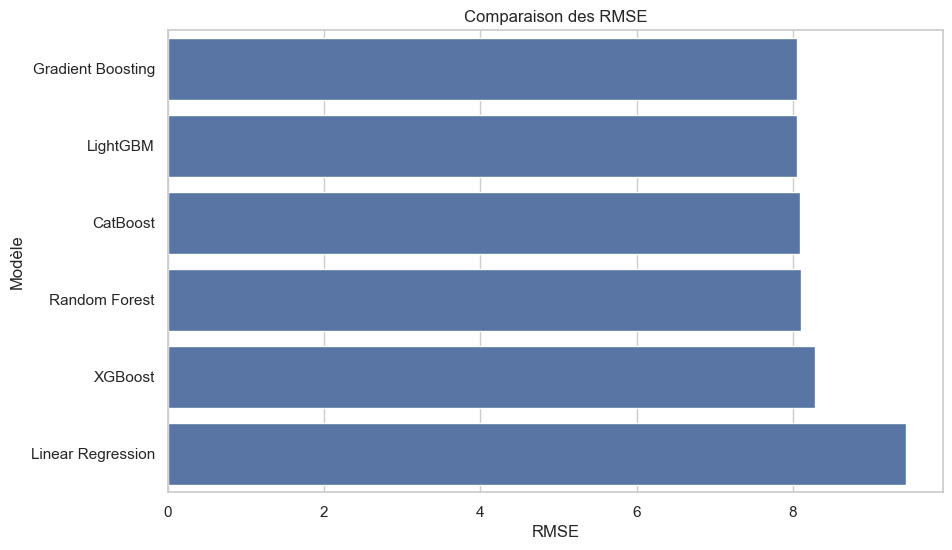

In [65]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="RMSE",
    y="Modele"
)

plt.title("Comparaison des RMSE")

plt.xlabel("RMSE")

plt.ylabel("Modèle")

plt.show()



#### Interprétation:

#### Le modèle présentant le RMSE le plus faible est celui qui réalise les prédictions les plus précises, en pénalisant davantage les erreurs importantes.


#### Comparaison MAE

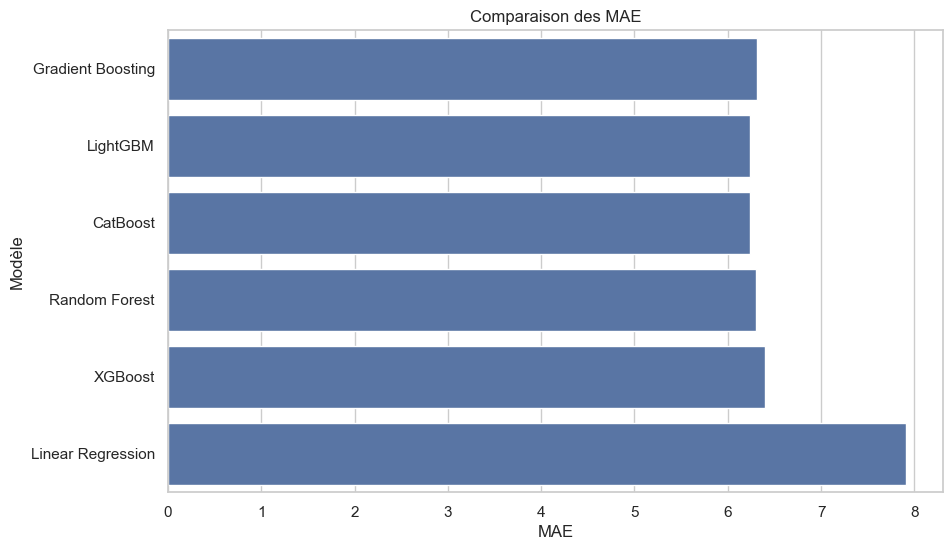

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="MAE",
    y="Modele"
)

plt.title("Comparaison des MAE")

plt.xlabel("MAE")

plt.ylabel("Modèle")

plt.show()


#### Interprétation: Le MAE représente l'erreur moyenne absolue entre les valeurs prédites et les valeurs réelles. 

#### Plus cette valeur est faible, plus le modèle est performant.


#### Comparaison MAPE

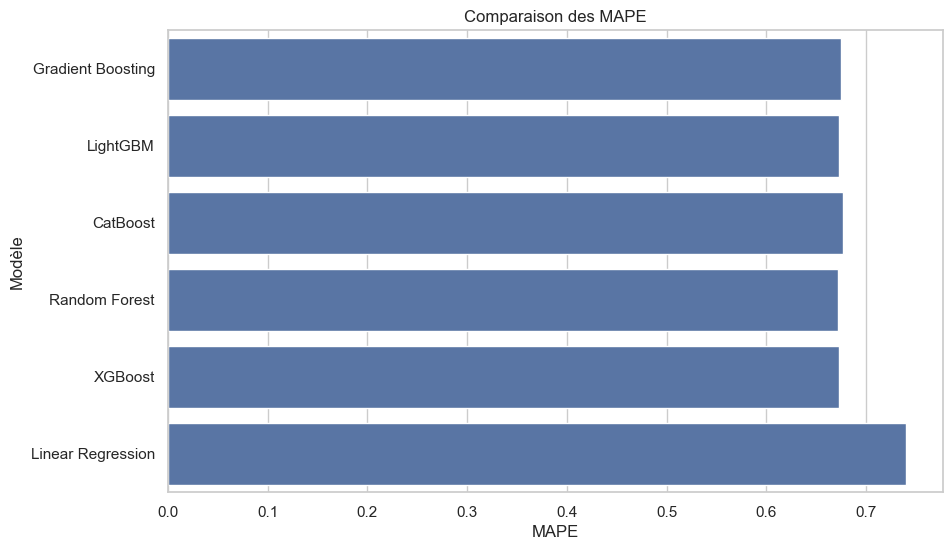

In [61]:

plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="MAPE",
    y="Modele"
)

plt.title("Comparaison des MAPE")

plt.xlabel("MAPE")

plt.ylabel("Modèle")

plt.show()


#### Interprétation:

#### Le MAPE mesure l'erreur moyenne en pourcentage. Un faible MAPE signifie que les prédictions sont proches des valeurs réelles en pourcentage.


#### Comparaison R²

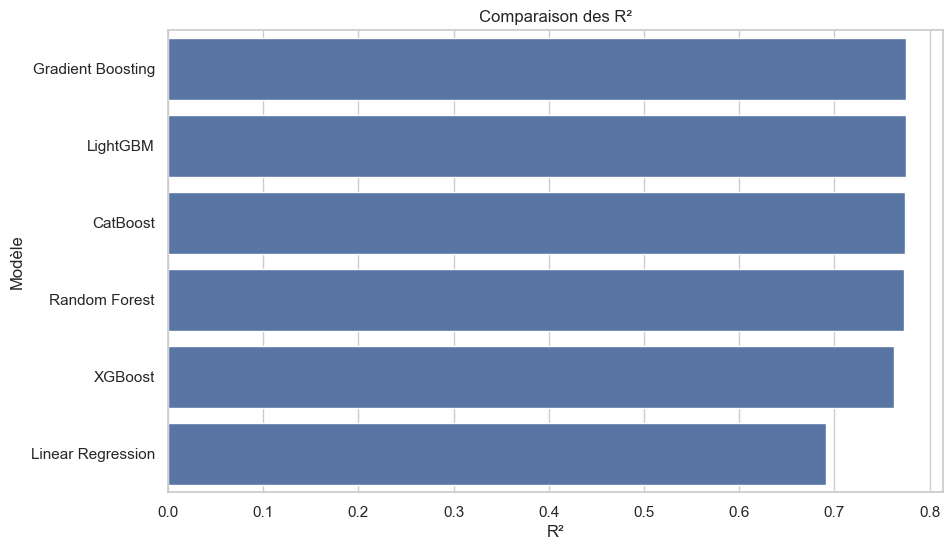

In [62]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="R2",
    y="Modele"
)

plt.title("Comparaison des R²")

plt.xlabel("R²")

plt.ylabel("Modèle")

plt.show()



#### Interprétation: Le coefficient de détermination (R²) mesure la capacité du modèle à expliquer la variabilité des données. 

#### Plus cette valeur est proche de 1, meilleure est la qualité des prédictions.


#### Temps d'entraînement

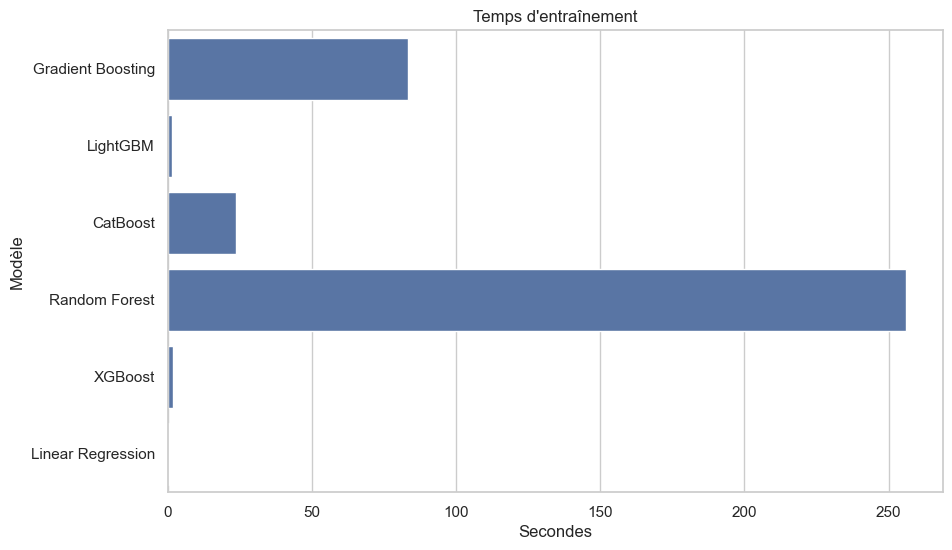

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="Temps_Entrainement",
    y="Modele"
)

plt.title("Temps d'entraînement")

plt.xlabel("Secondes")

plt.ylabel("Modèle")

plt.show()


#### Interprétation: Cette comparaison permet d'évaluer le coût de calcul de chaque modèle.

#### Un modèle très précis mais nécessitant un temps d'entraînement important peut être moins adapté à certaines applications.


#### Temps de prédiction

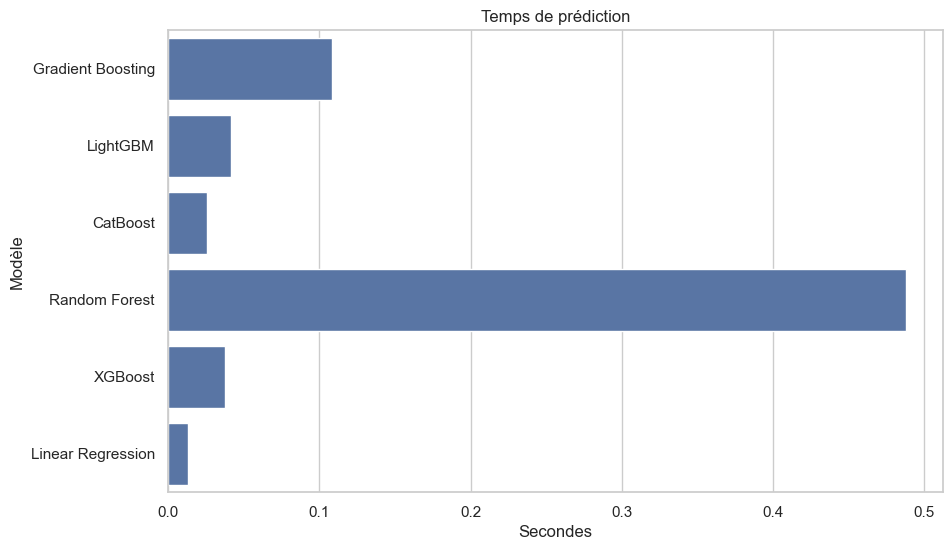

In [64]:

plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="Temps_Prediction",
    y="Modele"
)

plt.title("Temps de prédiction")

plt.xlabel("Secondes")

plt.ylabel("Modèle")

plt.show()